# Visual RAG 기반 시각 질의응답 서비스

**시각 질의응답(VQA)** 실습 — FastAPI 백엔드와 **Streamlit** 웹 UI를 연결해
한글 질문 → 이미지 검색 → 센서 연계 → Qwen3-VL 답변까지 **엔드투엔드 서비스**를 완성합니다.

> **선행 학습**: `02_conveyor_belt_visual_rag.ipynb`(인덱스 구축) · `03_analysis_vectordb_api_deploy.ipynb`(API·분석 벡터 DB)

## 전체 흐름

```
03 노트북 (FastAPI + 분석 벡터 DB)
       ↓
Streamlit Dashboard (웹 UI)
       │  HTTP requests
       ↓
FastAPI (/search · /analyze · /sensor · /history · /analysis/search)
       ↓
Visual RAG 파이프라인
  SigLIP2 검색 + 센서 메타 + Qwen3-VL 생성
       ↓
사용자에게 이미지·수치·분석 텍스트 표시
```

| 계층 | 기술 | 역할 |
|------|------|------|
| **UI** | Streamlit | 검색·분석·센서·이력 탭, 한글 질의 입력 |
| **API** | FastAPI | 모델·벡터 DB 접근, REST 엔드포인트 |
| **RAG** | SigLIP2 + ChromaDB | 관련 프레임 검색 |
| **생성** | Qwen3-VL | 검색 이미지 + 센서 종합 답변 |
| **지식** | 분석 벡터 DB | 과거 분석 결과 의미 검색 |

### 시각 질의응답(VQA)이란?

- 사용자가 **자연어 질문**을 하면, 시스템이 **관련 이미지를 찾고** VLM이 **시각적 근거**를 바탕으로 답합니다.
- 이 실습에서는 "컨베이어 벨트 이상 징후가 보이나?" 같은 질문에 대해
  **Top-k 프레임 + 센서 수치 + Qwen3-VL 분석**을 한 화면에 제공합니다.

### 모듈 소스 참조

노트북은 Streamlit 앱과 동일한 API를 `requests`로 호출합니다. UI 소스는 아래를 참고하세요.

📄 **[00_모듈_참조.md](00_모듈_참조.md)** — 경로별 파일 목록 + 기능 요약

| 노트북·UI에서 사용 | 경로 |
|-------------------|------|
| Streamlit 대시보드 | `conveyor_analyze/dashboard/streamlit_app.py` |
| FastAPI (HTTP 호출) | `conveyor_analyze/api/main.py` |
| API 실행 스크립트 | `conveyor_analyze/scripts/run_api.py` |
| 한글 차트 | `conveyor_analyze/conveyor_rag/plot_utils.py` |

## 0. 환경 설정

| 기술 | 역할 |
|------|------|
| **Streamlit** | 웹 기반 VQA 대시보드 (별도 터미널 실행) |
| **FastAPI** | Visual RAG 백엔드 API (포트 8000) |
| **requests** | 노트북에서 API 호출·UI 동작 시뮬레이션 |
| **matplotlib** | 검색 프레임·센서 차트 시각화 |

**사전 준비**
<br>
1. `02` 노트북으로 `data/conveyor/frames`, `chroma_db` 생성<br>
2. `03` 노트북으로 분석 벡터 DB·API 이해 (선택: `/analyze` 1회 실행)<br>
3. `conveyor_analyze` 폴더와 `Conveyor_Belt_Sample.zip` 준비<br>

> 이 노트북은 **Colab에서 실행 불가**합니다. 로컬에서 FastAPI + Streamlit을 별도 터미널로 띄워야 합니다.

In [1]:
# !pip install -r conveyor_analyze/requirements.txt
# 선행: 02·03 노트북 + conveyor_analyze 폴더

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Markdown, display
from PIL import Image

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data" / "conveyor"
FRAMES_DIR = DATA_DIR / "frames"
SENSOR_CSV = DATA_DIR / "sensor.csv"
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
STREAMLIT_APP = CONVEYOR_ANALYZE / "dashboard" / "streamlit_app.py"
API_BASE = "http://127.0.0.1:8000"

sys.path.insert(0, str(CONVEYOR_ANALYZE))
from conveyor_rag.plot_utils import setup_korean_matplotlib

_korean_font = setup_korean_matplotlib()

API_TIMEOUT_LIGHT = 30
API_TIMEOUT_SEARCH = 180
API_TIMEOUT_ANALYZE = 900

if not FRAMES_DIR.exists() or not list(FRAMES_DIR.glob("frame*.jpg")):
    raise FileNotFoundError(
        "02 노트북을 먼저 실행해 data/conveyor/frames 를 생성하세요."
    )

print(f"ROOT: {ROOT}")
print(f"프레임: {len(list(FRAMES_DIR.glob('frame*.jpg')))}장")
print(f"Streamlit 앱: {STREAMLIT_APP.exists()}")
print(f"matplotlib 한글 폰트: {_korean_font or '미설정'}")


def api_get(path, **params):
    r = requests.get(f"{API_BASE}{path}", params=params, timeout=API_TIMEOUT_LIGHT)
    r.raise_for_status()
    return r.json()


def api_post(path, payload, timeout=None):
    if timeout is None:
        timeout = API_TIMEOUT_ANALYZE if path == "/analyze" else API_TIMEOUT_SEARCH
    r = requests.post(f"{API_BASE}{path}", json=payload, timeout=timeout)
    r.raise_for_status()
    return r.json()


def check_api():
    try:
        return api_get("/")
    except (requests.ConnectionError, requests.ReadTimeout):
        return None

search_data = None  # 섹션 3 검색 결과 (선택)

ROOT: C:\MyCursorLab\09_Visual_RAG
프레임: 20장
Streamlit 앱: True
matplotlib 한글 폰트: Malgun Gothic


## 1. 3-Tier 서비스 아키텍처

```
┌─────────────────────────────────────────┐
│  Streamlit Dashboard  (포트 8501)        │
│  검색 · 분석 · 센서 · 이력 · 파이프라인    │
└──────────────────┬──────────────────────┘
                   │ HTTP (JSON)
┌──────────────────▼──────────────────────┐
│  FastAPI  (포트 8000)                    │
│  /search /analyze /sensor /history ...   │
└──────────────────┬──────────────────────┘
                   │
     ┌─────────────┼─────────────┐
     ▼             ▼             ▼
 ChromaDB      sensor.csv    Qwen3-VL
 (이미지·분석)   (메타)        (생성)
```

- **UI와 모델 분리**: Streamlit은 GPU 모델을 직접 로드하지 않고 API만 호출합니다.
- **확장성**: API는 Streamlit 외에 모바일·다른 웹앱에서도 재사용 가능합니다.

In [3]:
status = check_api()
if status is None:
    display(Markdown(
        "**API 서버 미실행** — 아래 터미널 명령으로 먼저 기동하세요.\n\n"
        "```bash\n"
        "cd conveyor_analyze\n"
        "python scripts/run_api.py\n"
        "```"
    ))
else:
    print("API 연결 OK")
    print(json.dumps(status, indent=2, ensure_ascii=False))

**API 서버 미실행** — 아래 터미널 명령으로 먼저 기동하세요.

```bash
cd conveyor_analyze
python scripts/run_api.py
```

## 2. Streamlit 대시보드 구조

`dashboard/streamlit_app.py`는 5개 탭으로 VQA 워크플로를 구성합니다.

| 탭 | 기능 | API |
|----|------|-----|
| 🔍 검색 | 텍스트 → SigLIP2 → Top-k 프레임 | `POST /search` |
| 🤖 분석 | Visual RAG 전체 (검색 + Qwen3-VL) | `POST /analyze` |
| 📊 센서 | sensor.csv 차트·프레임별 조회 | `GET /sensor` |
| 📜 이력 | 과거 분석 JSON 이력 | `GET /history` |
| ⚙️ 파이프라인 | 데이터 준비·실행 가이드 | (로컬 CLI) |

사이드바에서 **API URL**을 변경할 수 있어 포트가 다를 때도 대응합니다.

In [4]:
# Streamlit 앱 핵심 구조 확인
if STREAMLIT_APP.exists():
    src = STREAMLIT_APP.read_text(encoding="utf-8")
    # 탭 정의·API 호출 부분만 출력
    start = src.find("tab_search")
    end = src.find("with tab_analyze")
    print("=== streamlit_app.py (검색 탭) ===")
    print(src[start:end][:900])
    print("\n... (이하 생략)")
else:
    print(f"파일 없음: {STREAMLIT_APP}")

=== streamlit_app.py (검색 탭) ===
tab_search, tab_analyze, tab_sensor, tab_history, tab_pipeline = st.tabs(
    ["🔍 검색", "🤖 분석", "📊 센서", "📜 이력", "⚙️ 파이프라인"]
)

with tab_search:
    st.subheader("텍스트 → SigLIP2 → ChromaDB 검색")
    query = st.text_input("검색 쿼리", value="컨베이어 벨트 이상 상태")
    top_k = st.slider("Top-k", 1, 10, 4)
    if st.button("검색 실행", key="search"):
        with st.spinner("검색 중..."):
            try:
                data = api_post("/search", {"query": query, "top_k": top_k})
                st.success(f"쿼리: {data['query']}")
                cols = st.columns(min(top_k, 4))
                for i, hit in enumerate(data["results"]):
                    meta = hit["metadata"]
                    sensor = hit.get("sensor", meta)  # enrich_hits_with_sensor 결과
                    with cols[i % len(cols)]:
                        path = meta.get("local_path", "")
                        if Path(path).exists():
   

... (이하 생략)


## 3. 검색 탭 실습 — "이상 상태 프레임 찾기"

Streamlit **검색 탭**과 동일하게 `POST /search`를 호출하고, 노트북에서 결과를 시각화합니다.

| 단계 | 설명 |
|------|------|
| 1 | 한글 쿼리 → SigLIP2 텍스트 임베딩 |
| 2 | ChromaDB 코사인 유사도 Top-k |
| 3 | 센서 메타 병합 후 프레임 이미지 표시 |

In [5]:
SEARCH_QUERY = "컨베이어 벨트 이상 상태"
SEARCH_TOP_K = 4


def show_search_results(query: str, top_k: int = 4):
    """Streamlit 검색 탭과 동일한 API 호출 + matplotlib 시각화."""
    if not check_api():
        print("API 서버를 먼저 실행하세요.")
        return None

    data = api_post("/search", {"query": query, "top_k": top_k})
    hits = data["results"]
    print(f"쿼리: {data['query']} | 결과 {len(hits)}건\n")

    cols = min(top_k, 4)
    fig, axes = plt.subplots(1, cols, figsize=(4 * cols, 4))
    if cols == 1:
        axes = [axes]

    rows = []
    for i, hit in enumerate(hits[:cols]):
        meta = hit["metadata"]
        sensor = hit.get("sensor", meta)
        path = meta.get("local_path", "")
        ax = axes[i]
        if Path(path).exists():
            ax.imshow(Image.open(path))
        ax.set_title(
            f"{meta.get('frame')}\n"
            f"sim={hit['similarity']:.3f} | {sensor.get('status')}"
        )
        ax.axis("off")
        rows.append({
            "frame": meta.get("frame"),
            "similarity": round(hit["similarity"], 3),
            "status": sensor.get("status"),
            "temp": sensor.get("temp"),
            "vibration": sensor.get("vibration"),
        })

    plt.suptitle(f"검색: {query}", fontsize=12)
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame(rows))
    return data


search_data = show_search_results(SEARCH_QUERY, SEARCH_TOP_K)

API 서버를 먼저 실행하세요.


## 4. 분석 탭 실습 — Visual RAG 질의응답

Streamlit **분석 탭**은 `POST /analyze`로 전체 VQA 파이프라인을 실행합니다.

```
질문 입력
  → SigLIP2 검색 (관련 프레임)
  → 센서 CSV 조회
  → Qwen3-VL (이미지 1장씩 분석 → 종합)
  → JSON 이력 + 분석 벡터 DB 저장
  → UI에 분석 텍스트 표시
```

| 항목 | 권장값 |
|------|--------|
| `top_k` | 2 (VRAM·시간 절약) |
| 소요 시간 | GPU 기준 약 3~8분 |
| 타임아웃 | 900초 (15분) |

In [6]:
RUN_ANALYZE = False  # True로 변경 후 실행 (GPU·시간 소요)
ANALYZE_QUERY = "컨베이어 벨트에서 이상 징후가 보이는 프레임을 찾고 원인을 분석하세요."


def show_analyze_result(query: str, top_k: int = 2):
    """Streamlit 분석 탭과 동일한 Visual RAG 질의응답."""
    if not check_api():
        print("API 서버를 먼저 실행하세요.")
        return None

    print(f"/analyze 호출 중... (최대 {API_TIMEOUT_ANALYZE}초)")
    result = api_post("/analyze", {
        "query": query,
        "top_k": top_k,
        "save_history": True,
    })

    frames = result.get("retrieved_frames", [])
    n = min(len(frames), 4)
    if n:
        fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
        if n == 1:
            axes = [axes]
        for i, frame in enumerate(frames[:n]):
            path = FRAMES_DIR / frame
            if path.exists():
                axes[i].imshow(Image.open(path))
            axes[i].set_title(frame)
            axes[i].axis("off")
        plt.suptitle("검색된 프레임 (Qwen3-VL 입력)")
        plt.tight_layout()
        plt.show()

    if result.get("sensor_data"):
        display(Markdown("### 센서 데이터"))
        display(pd.DataFrame(result["sensor_data"]))

    display(Markdown("### Qwen3-VL 분석 결과"))
    display(Markdown(result.get("analysis", "")))
    print(f"history_id: {result.get('history_id')}")
    print(f"analysis_vector_id: {result.get('analysis_vector_id')}")
    return result


if RUN_ANALYZE and check_api():
    try:
        analyze_result = show_analyze_result(ANALYZE_QUERY, top_k=2)
    except requests.ReadTimeout:
        print(f"ReadTimeout — {API_TIMEOUT_ANALYZE}초 내 응답 없음. top_k=1 로 재시도하세요.")
elif RUN_ANALYZE:
    print("API 서버를 먼저 실행하세요.")
else:
    print("RUN_ANALYZE = True 로 설정하면 /analyze VQA를 실행합니다.")
    print("Streamlit 분석 탭에서도 동일한 API를 호출합니다.")

RUN_ANALYZE = True 로 설정하면 /analyze VQA를 실행합니다.
Streamlit 분석 탭에서도 동일한 API를 호출합니다.


## 5. 센서 탭 실습 — 시각 + 계측 연계

Streamlit **센서 탭**은 `sensor.csv`를 차트로 보여 주고, `GET /sensor`로 개별 프레임을 조회합니다.
VQA 답변의 **수치 근거**를 확인하는 데 사용합니다.

sensor.csv: 20행 | 필터=Fault → 9행


,frame,machine,temp,rpm,vibration,current,speed,status
3,frame0004.jpg,M01,48.8,1260,0.45,4.1,0.98,Fault
4,frame0005.jpg,M01,49.3,1261,0.47,4.1,0.98,Fault
5,frame0006.jpg,M01,49.9,1270,0.51,4.2,0.98,Fault
6,frame0007.jpg,M01,49.9,1265,0.49,4.3,0.98,Fault
12,frame0013.jpg,M01,54.7,1292,0.65,4.9,0.99,Fault


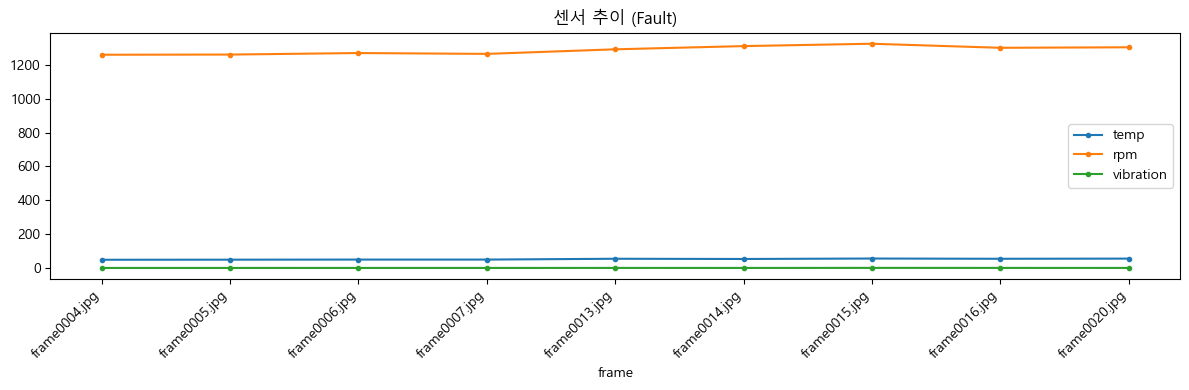

In [7]:
STATUS_FILTER = "Fault"  # Normal | Warning | Fault | None(전체)

df_sensor = pd.read_csv(SENSOR_CSV)
plot_df = df_sensor if not STATUS_FILTER else df_sensor[df_sensor["status"] == STATUS_FILTER]

print(f"sensor.csv: {len(df_sensor)}행 | 필터={STATUS_FILTER or '전체'} → {len(plot_df)}행")
display(plot_df.head())

ax = plot_df.set_index("frame")[["temp", "rpm", "vibration"]].plot(figsize=(12, 4), marker="o", ms=3)
ax.set_title(f"센서 추이 ({STATUS_FILTER or '전체'})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if check_api():
    frame_sel = "frame0003.jpg"
    sensor_one = api_get("/sensor", frame=frame_sel)
    print(f"\n[GET /sensor] {frame_sel}")
    print(json.dumps(sensor_one, indent=2, ensure_ascii=False))

## 6. 이력·과거 분석 검색 — 지식 재활용

VQA 서비스는 **매번 Qwen3-VL을 호출**하지 않아도 됩니다.
03 노트북에서 구축한 **분석 벡터 DB**로 유사한 과거 답변을 먼저 찾을 수 있습니다.

| API | 용도 |
|-----|------|
| `GET /history` | JSON 원문 이력 (Streamlit 이력 탭) |
| `POST /analysis/search` | 의미 기반 과거 분석 검색 |

In [8]:
if check_api():
    # 분석 이력 (Streamlit 이력 탭)
    history = api_get("/history", limit=5)
    print(f"[GET /history] 최근 {len(history.get('history', []))}건")
    for item in history.get("history", [])[:3]:
        print(f"  #{item.get('id')} | {item.get('query', '')[:40]}...")

    # 과거 분석 벡터 검색
    av = api_get("/analysis/vectors")
    if av.get("count", 0) > 0:
        past_q = "진동 이상"
        asearch = api_post("/analysis/search", {"query": past_q, "top_k": 3})
        print(f"\n[POST /analysis/search] '{past_q}'")
        rows = []
        for h in asearch["results"]:
            meta = h["metadata"]
            rows.append({
                "id": h["id"],
                "similarity": round(h["similarity"], 3),
                "query": meta.get("query", "")[:30],
                "analysis": meta.get("analysis", "")[:60] + "...",
            })
        display(pd.DataFrame(rows))
    else:
        print("\n분석 벡터 DB 비어 있음 — 03 노트북 또는 /analyze 실행 후 재시도")
else:
    print("API 서버를 먼저 실행하세요.")

API 서버를 먼저 실행하세요.


## 7. Streamlit 대시보드 실행

터미널 **2개**를 사용합니다.

**터미널 1 — API 서버**
```bash
cd conveyor_analyze
python scripts/run_pipeline.py   # 최초 1회 (인덱스 없을 때)
python scripts/run_api.py        # http://127.0.0.1:8000
```

**터미널 2 — Streamlit UI**
```bash
cd conveyor_analyze
streamlit run dashboard/streamlit_app.py
```

브라우저에서 `http://localhost:8501` 이 열립니다.

| 확인 사항 | 기대 결과 |
|-----------|----------|
| 사이드바 | "API 서버 연결됨" (녹색) |
| 검색 탭 | 쿼리 입력 → 프레임·유사도·센서 표시 |
| 분석 탭 | Qwen3-VL 분석 텍스트 + 프레임 그리드 |
| 센서 탭 | sensor.csv 테이블·라인 차트 |

> 포트 8000이 사용 중이면 `python scripts/run_api.py 8001` 후 Streamlit 사이드바 API URL을 변경하세요.

In [9]:
# Streamlit 실행 명령 안내 (노트북 셀에서는 직접 기동하지 않음 — 별도 터미널 권장)
import socket


def port_open(port: int) -> bool:
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(("127.0.0.1", port)) == 0


api_up = port_open(8000)
ui_up = port_open(8501)

print("서비스 상태")
print(f"  FastAPI  (8000): {'실행 중' if api_up else '미실행'}")
print(f"  Streamlit(8501): {'실행 중' if ui_up else '미실행'}")
print()
if not ui_up:
    print("Streamlit 실행:")
    print(f"  cd {CONVEYOR_ANALYZE}")
    print("  streamlit run dashboard/streamlit_app.py")

서비스 상태
  FastAPI  (8000): 미실행
  Streamlit(8501): 미실행

Streamlit 실행:
  cd C:\MyCursorLab\09_Visual_RAG\conveyor_analyze
  streamlit run dashboard/streamlit_app.py


## 8. 엔드투엔드 VQA 시나리오

아래는 실제 사용자가 Streamlit에서 수행하는 **시각 질의응답** 시나리오입니다.

```
1. [검색] "벨트 표면에 균열이나 이물질이 보이나?"
      → Top-4 프레임 + Fault/Warning 센서 확인

2. [분석] "이상 징후 원인과 조치 방안을 분석하세요"
      → Qwen3-VL이 이미지·센서를 종합해 답변 생성

3. [이력] 방금 분석이 JSON + 분석 벡터 DB에 저장됨

4. [재질의] "과열 관련 과거 분석 있나?"
      → /analysis/search 로 유사 답변 즉시 조회 (선택)
```

In [10]:
VQA_SCENARIOS = [
    "벨트 표면에 이물질이나 손상이 보이나?",
    "온도나 진동이 높은 구간은 어디인가?",
    "Fault 상태 프레임의 공통 특징은?",
]

print("추천 VQA 질문 (Streamlit 검색·분석 탭에 입력)")
for i, q in enumerate(VQA_SCENARIOS, 1):
    print(f"  {i}. {q}")

if check_api() and search_data is None:
    # 검색 셀을 건너뛴 경우 첫 시나리오만 빠르게 실행
    show_search_results(VQA_SCENARIOS[0], top_k=3)

추천 VQA 질문 (Streamlit 검색·분석 탭에 입력)
  1. 벨트 표면에 이물질이나 손상이 보이나?
  2. 온도나 진동이 높은 구간은 어디인가?
  3. Fault 상태 프레임의 공통 특징은?


## 9. 서비스 상태 점검

배포 전·실습 후 아래 항목을 확인합니다.

In [11]:
def report_vqa_service():
    report = {
        "frames": len(list(FRAMES_DIR.glob("frame*.jpg"))),
        "sensor_csv": SENSOR_CSV.exists(),
        "streamlit_app": STREAMLIT_APP.exists(),
        "api_port_8000": port_open(8000),
        "streamlit_port_8501": port_open(8501),
    }
    api_status = check_api()
    report["api_online"] = api_status is not None
    if api_status:
        report["image_vectors"] = api_status.get("vectors")
        report["analysis_vectors"] = api_status.get("analysis_vectors")
    display(pd.DataFrame([report]).T.rename(columns={0: "값"}))


report_vqa_service()

,값
frames,20
sensor_csv,True
streamlit_app,True
api_port_8000,False
streamlit_port_8501,False
api_online,False


## 요약

| 실습 | 내용 |
|------|------|
| **3-Tier 아키텍처** | Streamlit(UI) + FastAPI + Visual RAG |
| **검색 VQA** | 한글 질의 → SigLIP2 → 프레임 + 센서 |
| **생성 VQA** | `/analyze` → Qwen3-VL 종합 답변 |
| **센서 연계** | 시각 검색 결과에 temp/rpm/vibration 병합 |
| **지식 재활용** | 분석 이력·벡터 DB로 과거 답변 검색 |
| **서비스 배포** | `run_api.py` + `streamlit run` 로컬 실행 |

**핵심**: Visual RAG VQA 서비스는 **검색(가벼움)** 과 **생성(정밀)** 을 API로 묶고,
Streamlit이 사용자에게 **이미지·수치·텍스트**를 한 화면에 제공합니다.

### 실습 시리즈

| 노트북 | 주제 |
|--------|------|
| 01 | CLIP + ChromaDB + Qwen3-VL 기초 |
| 02 | 컨베이어 Visual RAG + 센서 |
| 03 | 분석 벡터 DB + FastAPI |
| **04** | **Streamlit 시각 질의응답 서비스** |
| 05 | 설비 이미지 기반 질의응답 실습 |